In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid') 
sns.set_palette("viridis")

In [2]:
df = pd.read_csv('./data/boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [4]:
df = df.astype({'CHAS':'bool'})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    bool   
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: bool(1), float64(12), int64(1)
memory usage: 52.0 KB


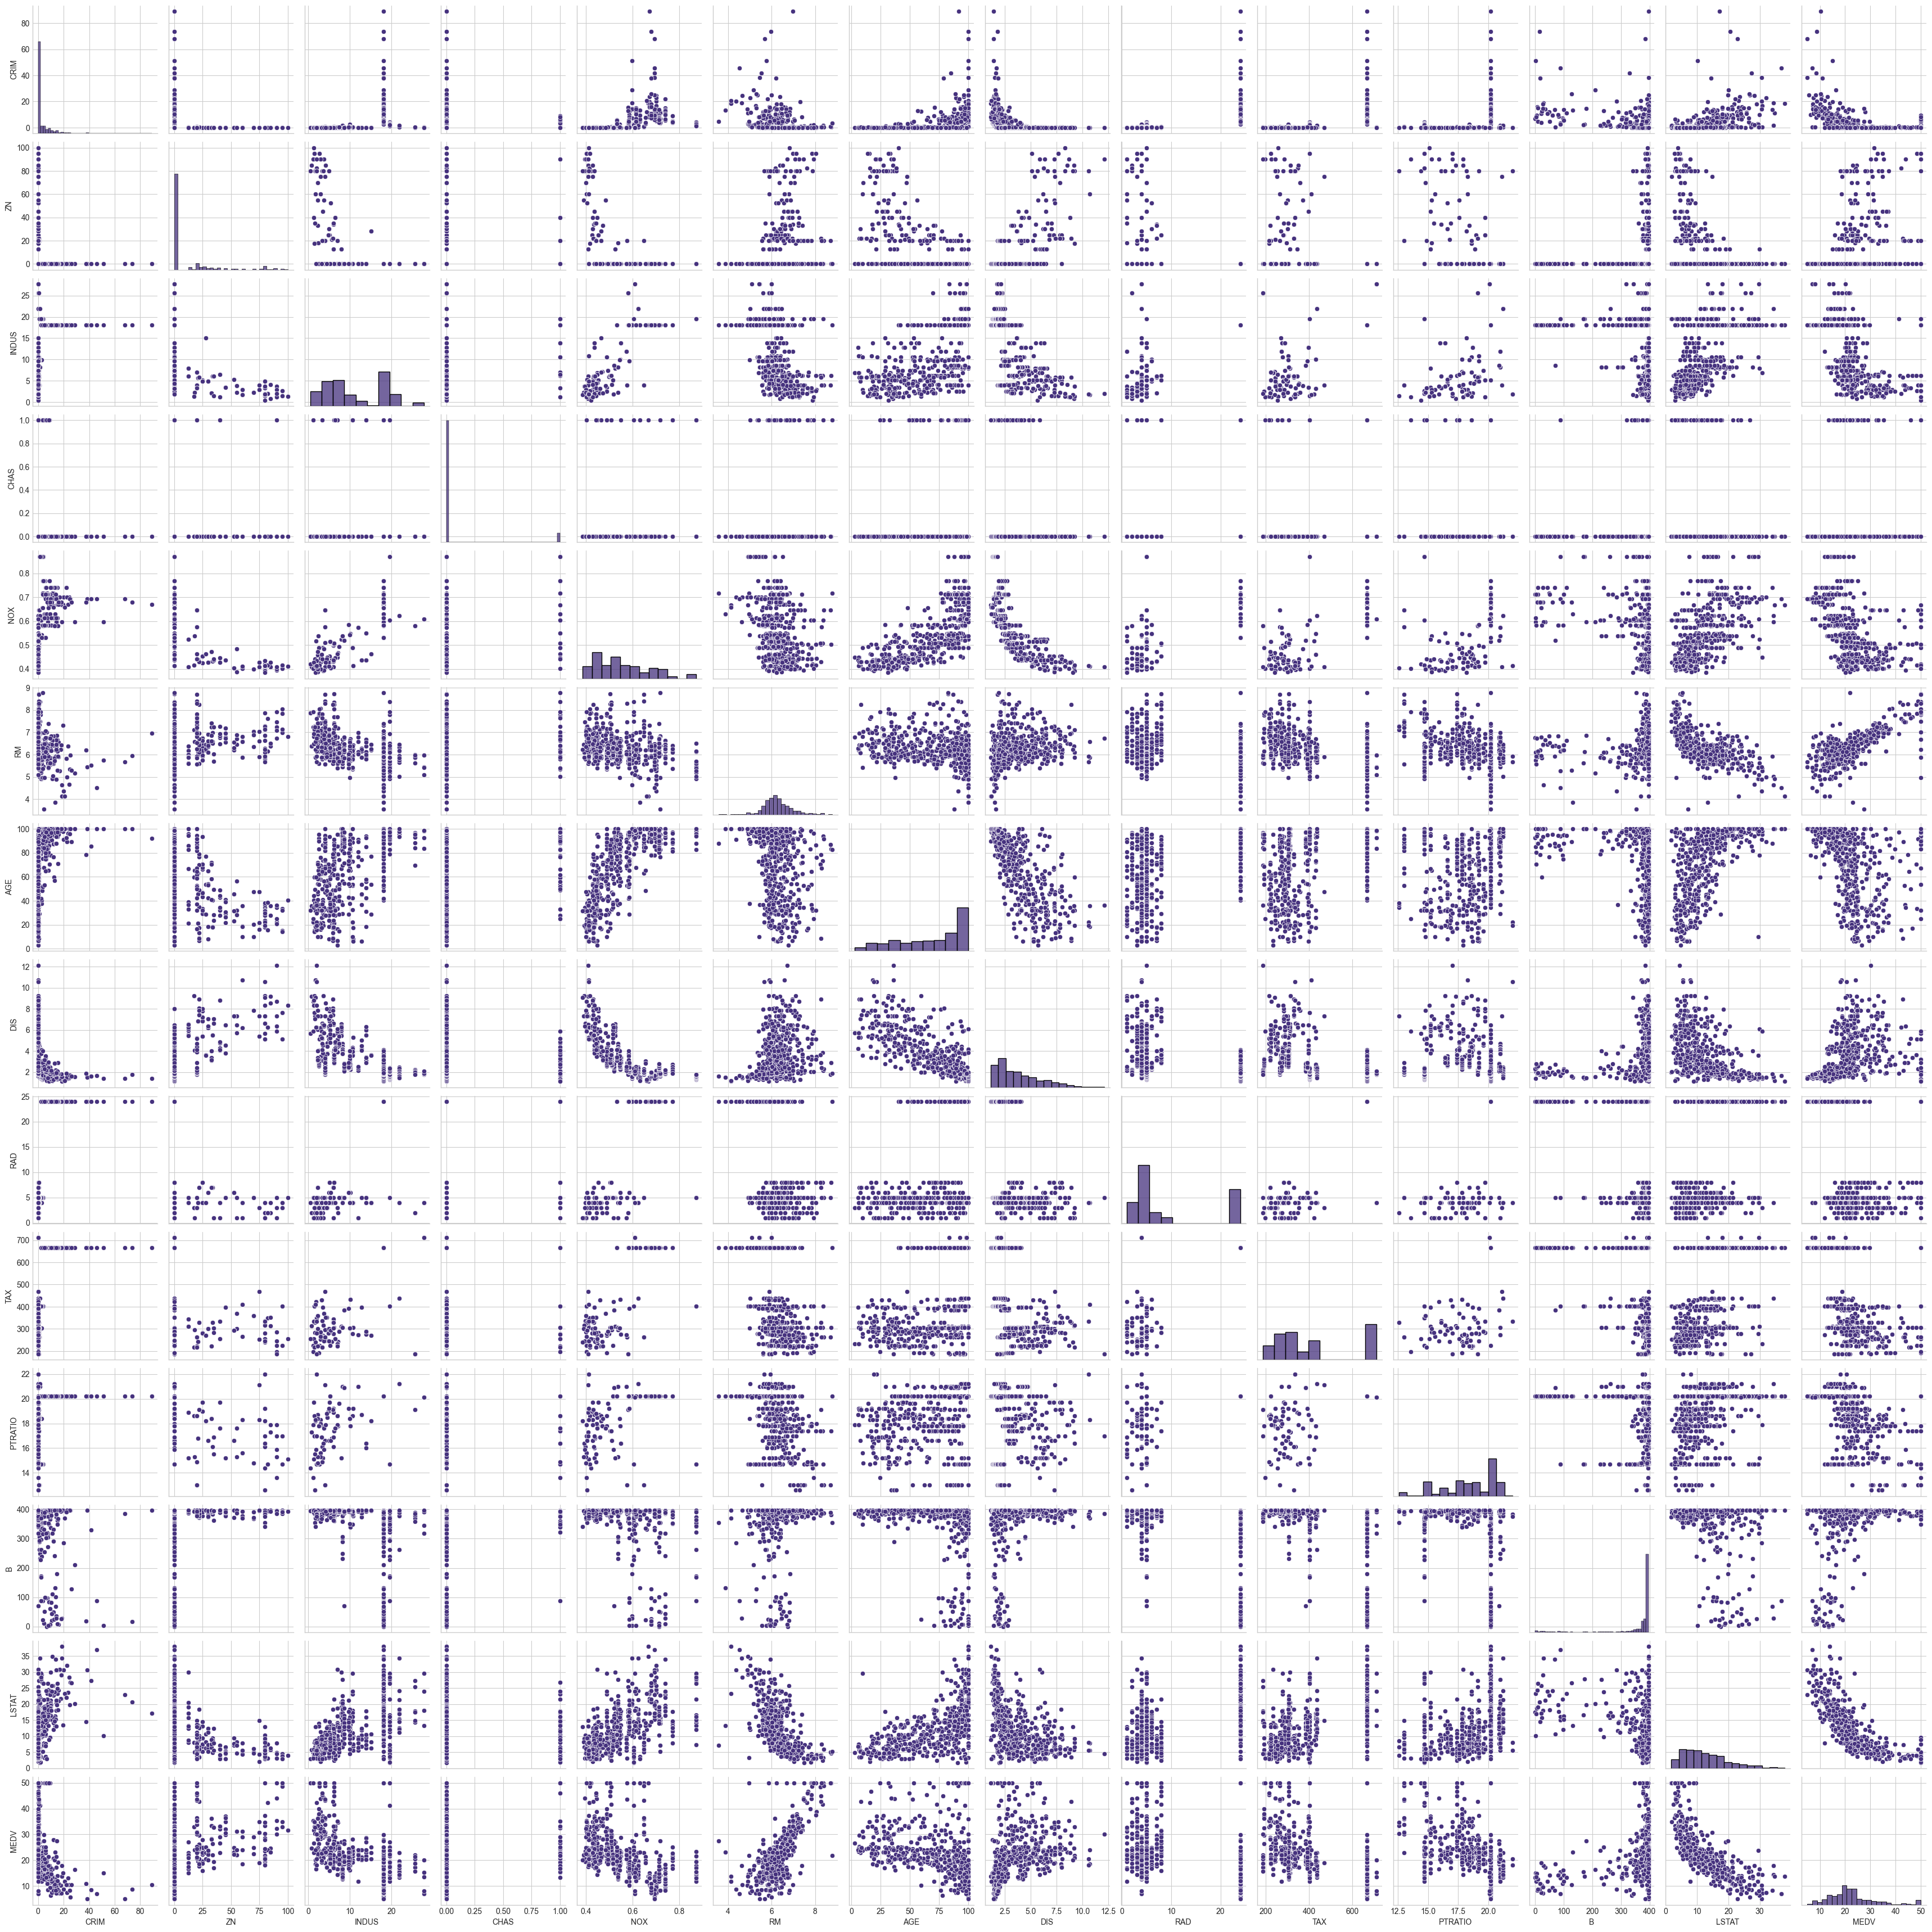

In [5]:
# df['CRIM'].hist(bins=50,density=True)

sns.pairplot(df)

In [6]:
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
df['CHAS'].value_counts()
# df['CHAS'].dtype

CHAS
False    471
True      35
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()
columns_standardize = ['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT']
df_std = scaler.fit_transform(df[columns_standardize])
type(df_std)
df_std = pd.DataFrame(df_std, columns=columns_standardize,index=df.index)
df_std.head()
df[columns_standardize] = df_std
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.419782,0.284830,-1.287909,False,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562,24.0
1,-0.417339,-0.487722,-0.593381,False,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439,21.6
2,-0.417342,-0.487722,-0.593381,False,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727,34.7
3,-0.416750,-0.487722,-1.306878,False,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517,33.4
4,-0.412482,-0.487722,-1.306878,False,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501,36.2


/var/folders/gq/wc_79v3d42j0mpv3x1wgp0v80000gn/T/ipykernel_65526/843095874.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_std, labels=df_std.columns)


{'whiskers': [<matplotlib.lines.Line2D at 0x13990a840>,
 'caps': [<matplotlib.lines.Line2D at 0x13990ade0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1384a3260>,
 'medians': [<matplotlib.lines.Line2D at 0x1399096d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x13990b560>,
 'means': []}

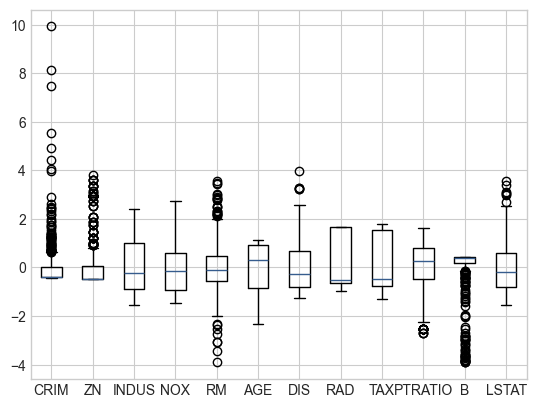

In [10]:
plt.boxplot(df_std, labels=df_std.columns)

In [11]:
df.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

<Axes: >

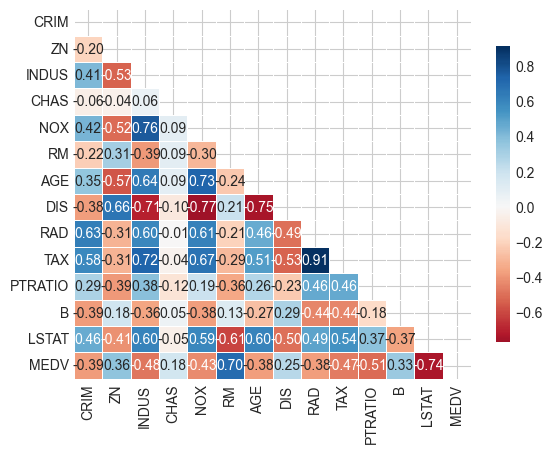

In [12]:
corr =df.corr()
type(corr)
msk = np.triu(np.ones_like(corr, dtype=bool))
mask = np.triu(np.ones_like(df.corr(), dtype=bool)) # Üst üçgeni gizler
sns.heatmap(df.corr(), mask=mask, annot=True, fmt=".2f", cmap='RdBu', center=0, 
            linewidths=.5, cbar_kws={"shrink": .8})


In [13]:
x = df.drop(columns=['MEDV'])
numerical_cols = x.select_dtypes(include=['int64','float64']).columns.tolist()
type(numerical_cols)
numerical_cols


['CRIM',
 'ZN',
 'INDUS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT']

In [14]:
columns_to_exclude = ['CHAS',"ZN","B"]

for col in x.columns:
    if col not in columns_to_exclude:
        s_col = x[col]
        q1 = s_col.quantile(0.25)
        q3 = s_col.quantile(0.75)
        iqr = q3 - q1   
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        s_col_clipped = s_col.clip(lower_bound, upper_bound)
        print(s_col_clipped.shape   )
        # df[col] = scaler.fit_transform(s_col_clipped.values.reshape(-1, 1))

(506,)
(506,)
(506,)
(506,)
(506,)
(506,)
(506,)
(506,)
(506,)
(506,)


In [15]:
#RM
q1 = x['RM'].quantile(0.25)
q3 = x['RM'].quantile(0.75)
print(q1, q3)
iqr = q3 - q1
lower_bound = q1 - 2.5 * iqr
upper_bound = q3 + 2.5 * iqr

x = x[(x['RM']<= upper_bound)&(x['RM']>=lower_bound)]
x.shape

-0.5686302678724634 0.4827678350928378


(501, 13)

In [ ]:
ind = df.corr()['MEDV'].abs().sort_values(ascending=False).head(6).index
type(ind  )


pandas.Index